In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import jax.numpy as jnp
from jax import grad, vmap
from matplotlib.colors import LogNorm
import jax
import random

from JAX_Deprojection import surface_brightness as sb
from JAX_Deprojection import density_distribution as den

In [2]:
s_def = 1. 

e_k_def = -0.4 
e_d_def = -0.1

p_a_def = 0.00160907
p_b_def = -0.02122767
p_c_def = 0.07711992
p_d_def = 0.54249868

q_a_def = 0.00105609
q_b_def = -0.0150896 
q_c_def = 0.07098185
q_d_def = 0.44305165

a_def = 2.
b_def = 4.
rho0_def = 0.001
i_def = 0.
phi_def = 0.
theta_def = 0.

size = 100
extent = 5
extents = [-extent, extent,-extent, extent]

res
 [-0.40001366 -0.0999926 ]
Optimzer route:  [Array(0., dtype=float32), Array([-0.01667597, -0.0532288 ], dtype=float32), Array([-0.05807339, -0.1491256 ], dtype=float32), Array([-0.07851767, -0.16489205], dtype=float32), Array([-0.10765928, -0.16904517], dtype=float32), Array([-0.1903577 , -0.16225345], dtype=float32), Array([-0.31369713, -0.13258207], dtype=float32), Array([-0.3903834 , -0.10233498], dtype=float32), Array([-0.39815596, -0.10007577], dtype=float32), Array([-0.39962178, -0.09995786], dtype=float32), Array([-0.40001366, -0.0999926 ], dtype=float32)]


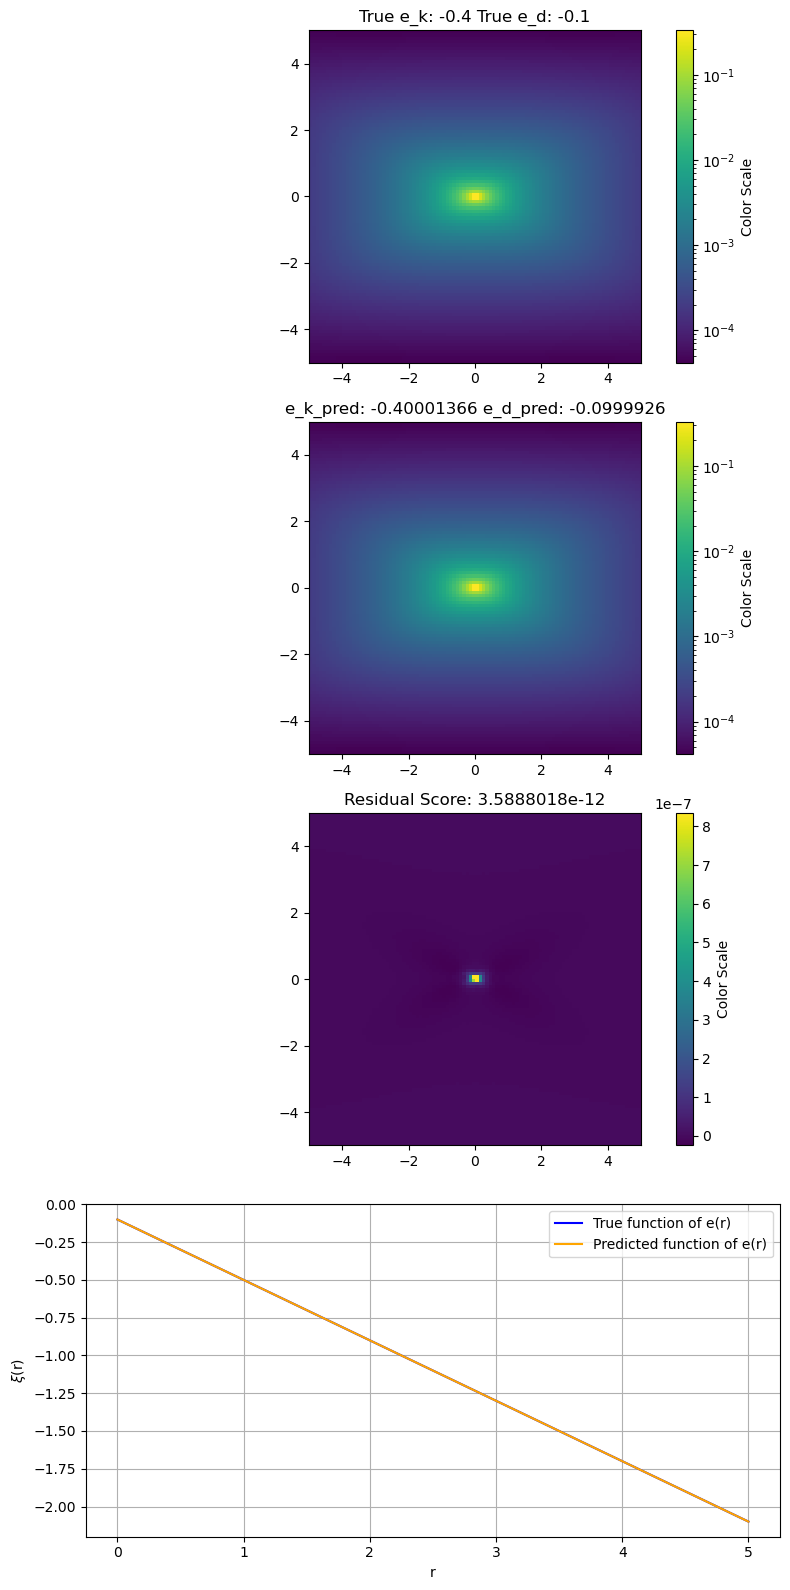

In [3]:


# Set up the figure and subplots
fig, axes = plt.subplots(4, figsize=(8,16))

# Plot data in each subplot


ax1 = axes[0]
ax2 = axes[1]
ax3 = axes[2]
ax4 = axes[3]

sb_1= sb.Surface_brightness()
sb_1.generate(size,extent, e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
fig.colorbar(img1, ax=ax1, label='Color Scale')
ax1.set_title("True e_k: "+str(e_k_def)+" True e_d: "+str(e_d_def))

bounds = ((-1.,-1.),(1.,1.))
starting_guess = [0.,0.]
initial_params = [starting_guess[0], starting_guess[1], p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def,rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def]
optimize_mask = [True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False]
pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,2,15,1.)
print("Optimzer route: ",res)

projected_pred_den = pred_den.project()
img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
fig.colorbar(img2, ax=ax2, label='Color Scale')
ax2.set_title("e_k_pred: "+str(res[-1][0])+" e_d_pred: "+str(res[-1][1]))

residual = sb_1.data - projected_pred_den.data
img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
fig.colorbar(img3, ax=ax3, label='Color Scale')
ax3.set_title("Residual Score: "+str(score))

lin_true = np.poly1d([e_k_def,e_d_def])
lin_pred = np.poly1d(res[-1])

# Generate x values for plotting (smooth curve)
x_values = np.linspace(0, 5, 100)
y_true = lin_true(x_values)
y_pred = lin_pred(x_values)

ax4.plot(x_values, y_true, label="True function of e(r)", color='blue')
ax4.plot(x_values, y_pred, label="Predicted function of e(r)", color='orange')

ax4.legend()
ax4.set_xlabel('r')
ax4.set_ylabel(r'$\xi$(r)')
ax4.grid(True)
# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

res
 [ 0.0018     -0.02        0.08661336  0.55995876]
Optimzer route:  [Array(0.005, dtype=float32), Array([ 0.0018  , -0.02    ,  0.1     ,  0.653615], dtype=float32), Array([ 0.0018    , -0.02      ,  0.08661336,  0.55995876], dtype=float32)]


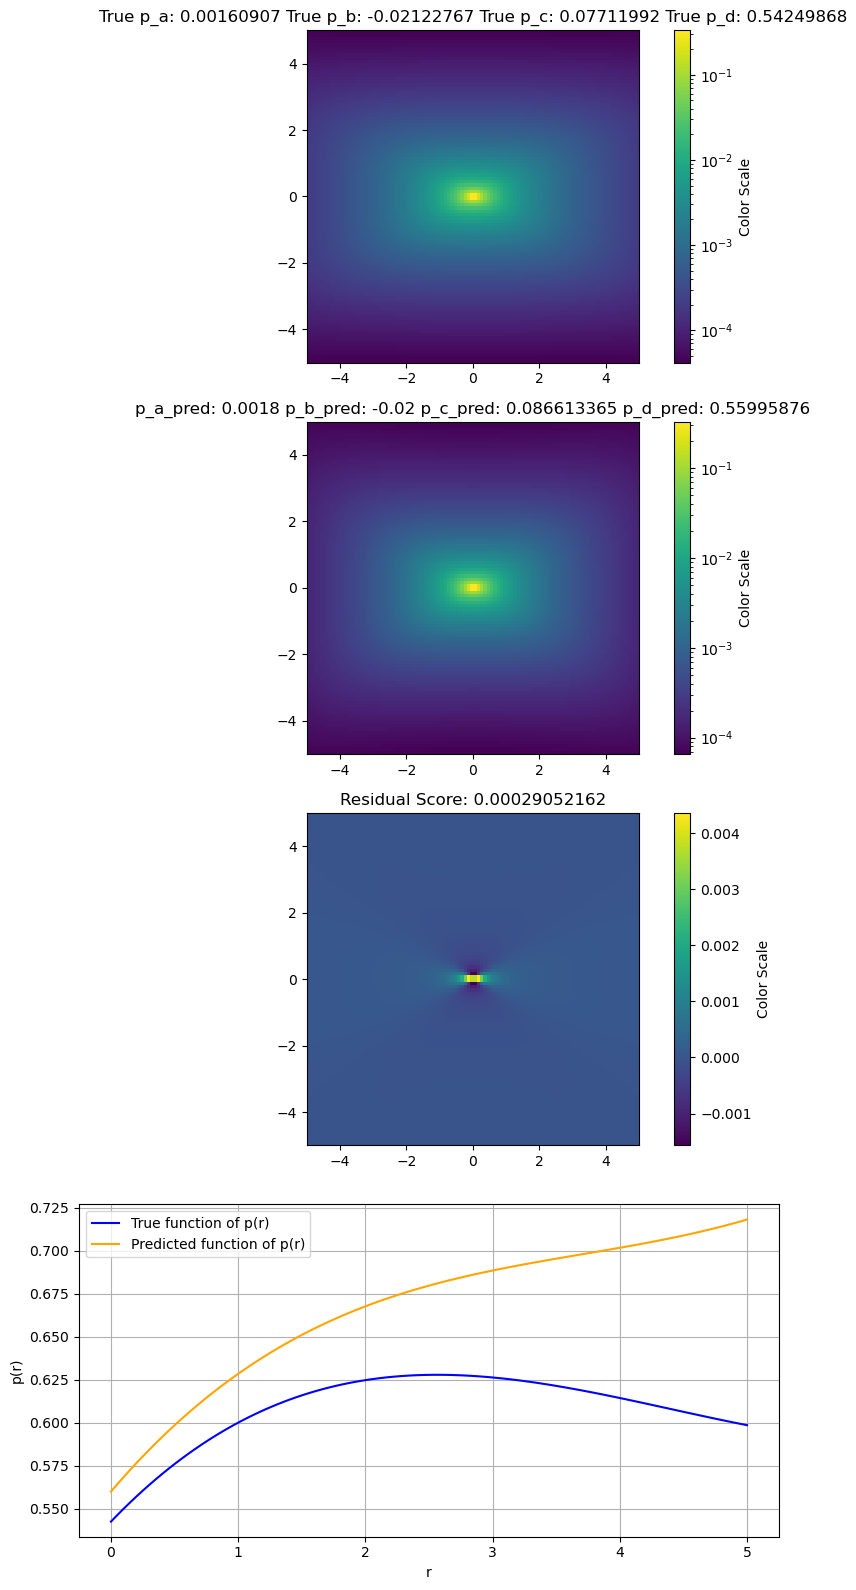

In [4]:

# Set up the figure and subplots
fig, axes = plt.subplots(4, figsize=(8,16))

# Plot data in each subplot


ax1 = axes[0]
ax2 = axes[1]
ax3 = axes[2]
ax4 = axes[3]

sb_1= sb.Surface_brightness()
sb_1.generate(size,extent, e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
fig.colorbar(img1, ax=ax1, label='Color Scale')
ax1.set_title("True p_a: "+str(p_a_def)+" True p_b: "+str(p_b_def)+" True p_c: "+str(p_c_def)+" True p_d: "+str(p_d_def))

bounds = ((-0.05,-0.05,-0.05,-0.8),(0.0018,-0.020,0.1,0.8))
starting_guess = [0.005,-0.02,0.05,0.4]
initial_params = [e_k_def, e_d_def, starting_guess[0], starting_guess[1], starting_guess[2], starting_guess[3], q_a_def, q_b_def, q_c_def, q_d_def,rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def]
optimize_mask = [False,False,True,True,True,True,False,False,False,False,False,False,False,False,False,False,False]
pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,4,13,1.)
print("Optimzer route: ",res)

projected_pred_den = pred_den.project()
img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
fig.colorbar(img2, ax=ax2, label='Color Scale')
ax2.set_title("p_a_pred: "+str(res[-1][0])+" p_b_pred: "+str(res[-1][1])+" p_c_pred: "+str(res[-1][2])+" p_d_pred: "+str(res[-1][3]))

residual = sb_1.data - projected_pred_den.data
img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
fig.colorbar(img3, ax=ax3, label='Color Scale')
ax3.set_title("Residual Score: "+str(score))

lin_true = np.poly1d([p_a_def, p_b_def, p_c_def, p_d_def])
lin_pred = np.poly1d(res[-1])

# Generate x values for plotting (smooth curve)
x_values = np.linspace(0, 5, 100)
y_true = lin_true(x_values)
y_pred = lin_pred(x_values)

ax4.plot(x_values, y_true, label="True function of p(r)", color='blue')
ax4.plot(x_values, y_pred, label="Predicted function of p(r)", color='orange')

ax4.legend()
ax4.set_xlabel('r')
ax4.set_ylabel('p(r)')
ax4.grid(True)
# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

res
 [ 0.003      -0.0145279   0.0616291   0.46150365]
Optimzer route:  [Array(0.005, dtype=float32), Array([ 0.003     , -0.0145279 ,  0.0616291 ,  0.46150365], dtype=float32)]


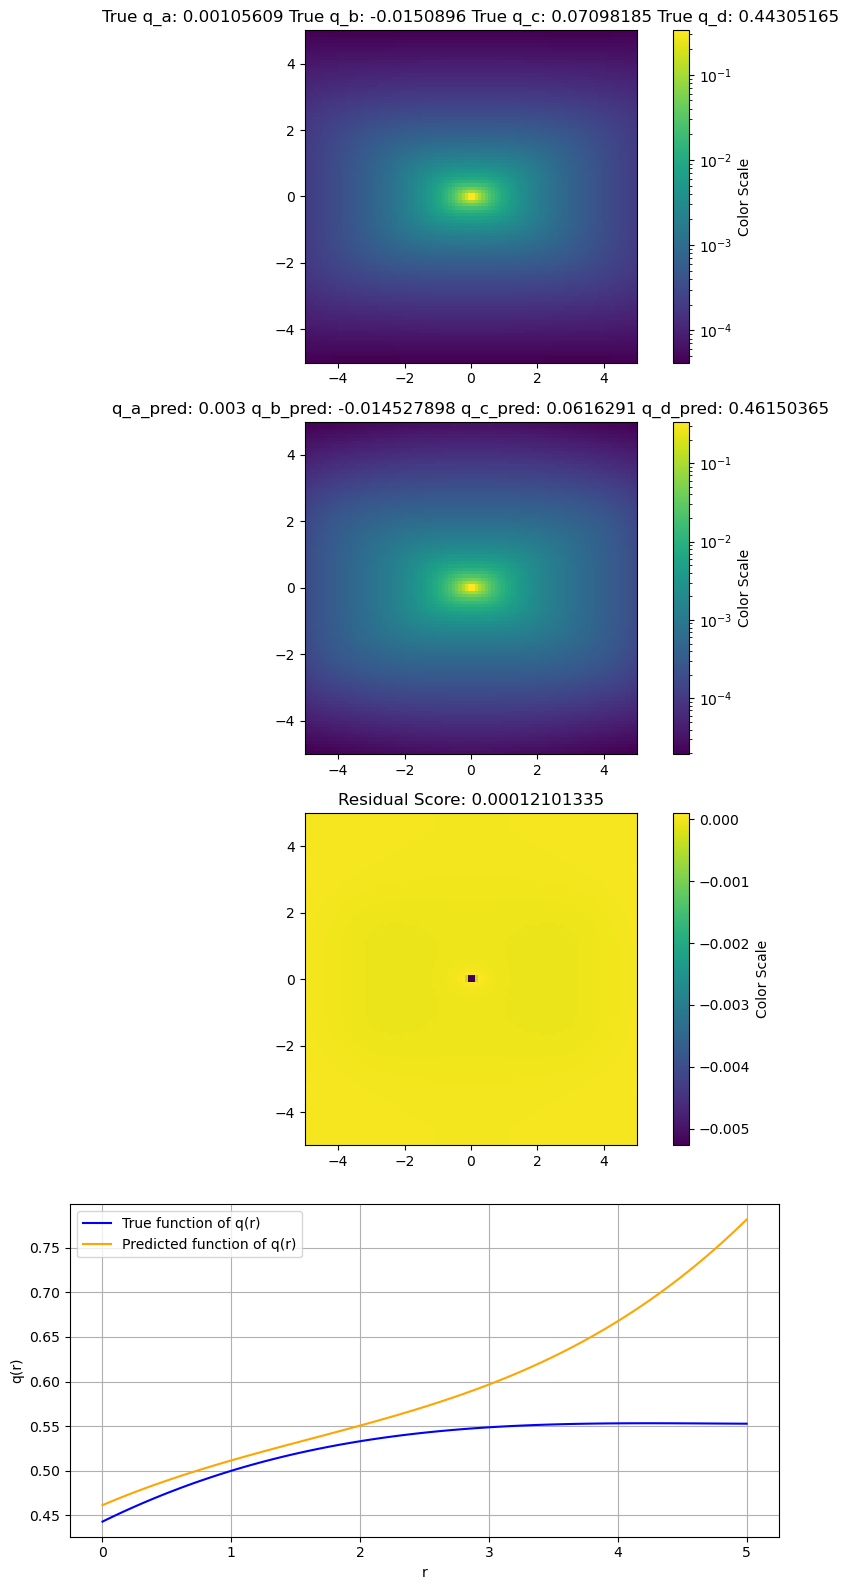

In [5]:
# Set up the figure and subplots
fig, axes = plt.subplots(4, figsize=(8,16))

# Plot data in each subplot


ax1 = axes[0]
ax2 = axes[1]
ax3 = axes[2]
ax4 = axes[3]

sb_1= sb.Surface_brightness()
sb_1.generate(size,extent, e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, q_a_def, q_b_def, q_c_def, q_d_def, rho0_def, s_def, a_def, b_def, i_def, phi_def, theta_def)
img1 = ax1.imshow(sb_1.data.T, norm=colors.LogNorm(vmin=sb_1.data.min(), vmax=sb_1.data.max()), origin='lower',extent = extents)
fig.colorbar(img1, ax=ax1, label='Color Scale')
ax1.set_title("True q_a: "+str(q_a_def)+" True q_b: "+str(q_b_def)+" True q_c: "+str(q_c_def)+" True q_d: "+str(q_d_def))

bounds = ((-0.05,-0.05,-0.05,-0.8),(0.003,-0.01,0.1,0.8))
starting_guess = [0.005,-0.02,0.05,0.4]
initial_params = [e_k_def, e_d_def, p_a_def, p_b_def, p_c_def, p_d_def, starting_guess[0], starting_guess[1], starting_guess[2], starting_guess[3],rho0_def,s_def,a_def,b_def,i_def,phi_def,theta_def]
optimize_mask = [False,False,False,False,False,False,True,True,True,True,False,False,False,False,False,False,False]
pred_den , res, score = sb_1.deproject( bounds, initial_params, optimize_mask,4,13,1.)
print("Optimzer route: ",res)

projected_pred_den = pred_den.project()
img2 = ax2.imshow(projected_pred_den.data.T, norm=colors.LogNorm(vmin=projected_pred_den.data.min(), vmax=projected_pred_den.data.max()), origin='lower',extent = extents)
fig.colorbar(img2, ax=ax2, label='Color Scale')
ax2.set_title("q_a_pred: "+str(res[-1][0])+" q_b_pred: "+str(res[-1][1])+" q_c_pred: "+str(res[-1][2])+" q_d_pred: "+str(res[-1][3]))

residual = sb_1.data - projected_pred_den.data
img3 = ax3.imshow(residual.T, origin='lower',extent = extents)
fig.colorbar(img3, ax=ax3, label='Color Scale')
ax3.set_title("Residual Score: "+str(score))

lin_true = np.poly1d([q_a_def, q_b_def, q_c_def, q_d_def])
lin_pred = np.poly1d(res[-1])

# Generate x values for plotting (smooth curve)
x_values = np.linspace(0, 5, 100)
y_true = lin_true(x_values)
y_pred = lin_pred(x_values)

ax4.plot(x_values, y_true, label="True function of q(r)", color='blue')
ax4.plot(x_values, y_pred, label="Predicted function of q(r)", color='orange')

ax4.legend()
ax4.set_xlabel('r')
ax4.set_ylabel('q(r)')
ax4.grid(True)
# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

When using very specific boundary conditions or starting values very close to the true values performance for the polynomial fit is good. But this is not realistic for real applications.